In [2]:
import pandas  as pd
import numpy as np

## Q1. Pandas version

In [3]:

pd.__version__

'3.0.3'

In [3]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [5]:
df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [7]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [8]:
df.head().T

,0,1,2,3,4
model_year,2006,2008,1996,1989,1994
origin,Europe,Europe,Asia,Europe,USA
fuel_type,Gasoline,Diesel,Gasoline,Gasoline,Diesel
drivetrain,Front-wheel drive,Front-wheel drive,Front-wheel drive,Front-wheel drive,Front-wheel drive
num_doors,4,4,5,4,3
engine_displacement,2180,2390,2320,2130,2580
num_cylinders,6,6,6,6,7
horsepower,243.0,272.0,267.0,258.0,304.0
vehicle_weight,3870,4210,4240,4490,4510
acceleration,NaN,NaN,17.3,18.7,17.5


## Q4. Missing values How many columns in the dataset have missing values?
2

In [9]:
# 检查数据集中的所有空值情况
print("=" * 50)  
print("快速检查:")
print("=" * 50)
print(df.isnull().sum())

快速检查:
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64


# Q2. Records count How many records are in the dataset? 
10000

In [10]:
df.count()

model_year             10000
origin                 10000
fuel_type              10000
drivetrain             10000
num_doors              10000
engine_displacement    10000
num_cylinders          10000
horsepower              9123
vehicle_weight         10000
acceleration            9736
fuel_efficiency_mpg    10000
dtype: int64

In [11]:
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


## Q3. Fuel types How many fuel types are presented in the dataset?

In [12]:
df.fuel_type.nunique()

3

In [13]:
df.fuel_type.unique()

<ArrowStringArray>
['Gasoline', 'Diesel', 'Hybrid']
Length: 3, dtype: str

## Q5. Max fuel efficiency What's the maximum fuel efficiency of cars from Asia?
41.2

In [14]:
df[df['origin'] == 'Asia'].loc[df[df['origin'] == 'Asia']['fuel_efficiency_mpg'].idxmax()]

model_year                          2022
origin                              Asia
fuel_type                         Diesel
drivetrain             Front-wheel drive
num_doors                              4
engine_displacement                 1990
num_cylinders                          6
horsepower                         225.0
vehicle_weight                      3870
acceleration                        17.2
fuel_efficiency_mpg                 41.2
Name: 6354, dtype: object

## Q6. Median value of horsepower Find the median value of the column in the dataset.horsepower Next, calculate the most frequent value of the same column.horsepower Use the method to fill the missing values in the column with the most frequent value from the previous step.fillnahorsepower Now, calculate the median value of once again.horsepower Has it changed?

Yes, it decreased

In [15]:
df['horsepower'].median() # 中位数

np.float64(254.0)

In [16]:
df['horsepower'].mode()[0] # 常见值

np.float64(252.0)

In [17]:
df['horsepower'].describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

In [18]:
df.horsepower.isnull().sum()

np.int64(877)

In [19]:
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mode()[0]) # 常见值填充空值

In [20]:
df.horsepower.isnull().sum()

np.int64(0)

In [21]:
df['horsepower'].median() # 中位数   #发现中位数增加了

np.float64(252.0)

## Q7. Sum of weights 

- 1- Select all the cars from Asia
- 2- Select only columns vehicle_weight and model_year
- 3- Select the first 7 values
- 4- Get the underlying NumPy array. Let's call it X.
- 5- Compute matrix-matrix multiplication between the transpose of X and X. To get the transpose, use X.T. Let's call the result XTX.
- 6- Invert XTX.
- 7- Create an array y with values [1100, 1300, 800, 900, 1000, 1100, 1200].
- 8- Multiply the inverse of XTX with the transpose of X, and then multiply the result by y. Call the result w.
- 9- What's the sum of all the elements of the result?
0.369

In [22]:
asia_cars = df[df['origin'] == 'Asia']
asia_cars

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
6,1992,Asia,Gasoline,Front-wheel drive,2,2270,6,250.0,4310,21.7,26.8
8,1997,Asia,Gasoline,Rear-wheel drive,3,2330,6,251.0,4230,19.5,30.9
10,1978,Asia,Gasoline,All-wheel drive,3,2410,6,252.0,4420,19.5,26.8
15,2007,Asia,Diesel,Front-wheel drive,4,2170,5,226.0,3950,18.0,35.4
...,...,...,...,...,...,...,...,...,...,...,...
9984,2011,Asia,Gasoline,Front-wheel drive,3,2410,6,256.0,4610,20.2,32.4
9987,2004,Asia,Diesel,All-wheel drive,3,2180,6,266.0,4530,18.6,29.0
9990,1975,Asia,Diesel,Front-wheel drive,4,1940,6,236.0,3630,19.7,32.4
9994,1993,Asia,Gasoline,Rear-wheel drive,2,2360,6,257.0,4610,22.2,30.1


In [23]:
asia_cars_subset = asia_cars[['vehicle_weight', 'model_year']]
asia_cars_subset

,vehicle_weight,model_year
2,4240,1996
6,4310,1992
8,4230,1997
10,4420,1978
15,3950,2007
...,...,...
9984,4610,2011
9987,4530,2004
9990,3630,1975
9994,4610,1993


In [24]:
first_7_rows = asia_cars_subset.head(7) 
first_7_rows

,vehicle_weight,model_year
2,4240,1996
6,4310,1992
8,4230,1997
10,4420,1978
15,3950,2007
16,4750,2021
22,4450,2019


In [25]:
X = first_7_rows.values
X

array([[4240, 1996],
       [4310, 1992],
       [4230, 1997],
       [4420, 1978],
       [3950, 2007],
       [4750, 2021],
       [4450, 2019]])

In [26]:
X_T = X.T
X_T

array([[4240, 4310, 4230, 4420, 3950, 4750, 4450],
       [1996, 1992, 1997, 1978, 2007, 2021, 2019]])

In [27]:
XTX = np.dot(X_T, X)
XTX

array([[131950500,  60750580],
       [ 60750580,  28041424]])

In [28]:
XTX_inv = np.linalg.inv(XTX)
XTX_inv

array([[ 2.96830537e-06, -6.43071025e-06],
       [-6.43071025e-06,  1.39675281e-05]])

In [29]:
X_unit_matrix = np.dot(XTX_inv,XTX) 
X_unit_matrix

array([[ 1.00000000e+00, -7.77917769e-15],
       [-8.75935812e-14,  1.00000000e+00]])

In [30]:
y = np.array([1100, 1300, 800, 900, 1000, 1100, 1200])

In [31]:
w = XTX_inv.dot(X_T).dot(y)
w

array([0.13644777, 0.2327492 ])

In [32]:
w_sum = w.sum()


In [33]:
w_sum

np.float64(0.36919696904925486)

### Look at the variable. Does it have a long tail?fuel_efficiency_mpg

In [34]:
df.fuel_efficiency_mpg.max()

np.float64(41.2)

In [35]:
df.fuel_efficiency_mpg.min()

np.float64(19.8)

In [36]:
df.fuel_efficiency_mpg.mean()

np.float64(29.9977)

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib  inline   


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

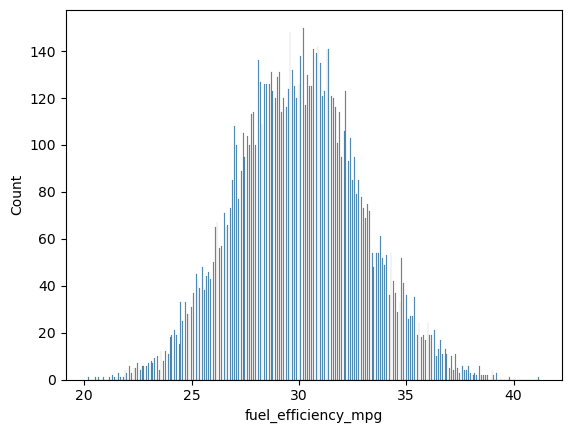

In [44]:
sns.histplot(df.fuel_efficiency_mpg[df.fuel_efficiency_mpg > 19.8 ],bins=500)

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

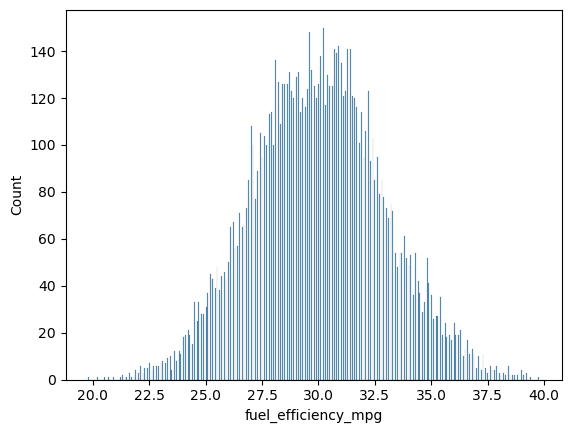

In [45]:
sns.histplot(df.fuel_efficiency_mpg[df.fuel_efficiency_mpg < 41.2 ],bins=500)

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

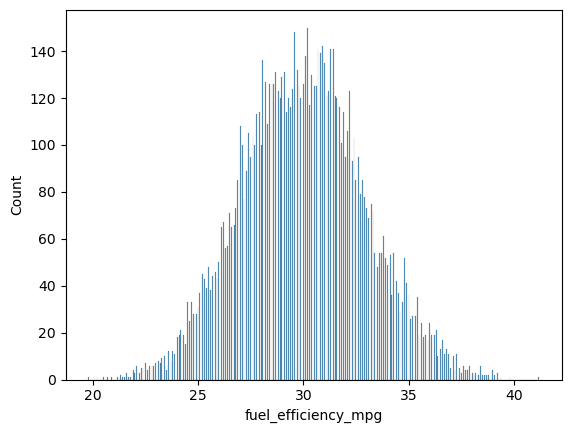

In [46]:
sns.histplot(df.fuel_efficiency_mpg,bins=500)

In [47]:
mpg_logs = np.log1p(df.fuel_efficiency_mpg) 

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

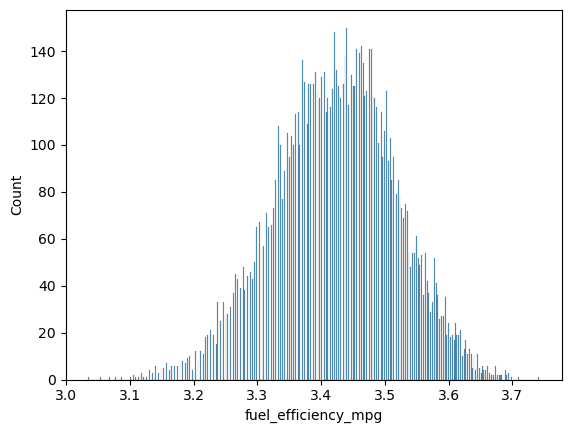

In [48]:
sns.histplot(mpg_logs,bins=500)

In [4]:
# 检查数据集中的所有空值情况
print("=" * 50)  
print("快速检查:")
print("=" * 50)
print(df.isnull().sum())

快速检查:
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64


In [5]:
df.describe()

,model_year,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
count,10000.000000,10000.00000,10000.000000,10000.000000,9123.000000,10000.000000,9736.000000,10000.000000
mean,1999.549500,3.50400,2268.807000,6.035200,254.446016,4286.754000,18.888044,29.997700
std,14.207925,0.95209,183.447355,0.542578,22.844613,266.212491,1.279543,2.930245
min,1975.000000,2.00000,1590.000000,4.000000,171.000000,3320.000000,14.000000,19.800000
25%,1987.000000,3.00000,2150.000000,6.000000,239.000000,4110.000000,18.000000,28.000000
50%,2000.000000,4.00000,2270.000000,6.000000,254.000000,4280.000000,18.900000,30.000000
75%,2012.000000,4.00000,2390.000000,6.000000,270.000000,4470.000000,19.700000,31.900000
max,2024.000000,5.00000,3110.000000,8.000000,334.000000,5460.000000,23.800000,41.200000


In [6]:
df.shape[0]

10000

In [7]:
n = len(df)
n_val = int(n*0.2) 
n_test = int(n*0.2)
n_train = n - n_val - n_test 
n,n_val + n_test + n_train

(10000, 10000)

In [8]:
n_val,n_test,n_train

(2000, 2000, 6000)

In [9]:
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx) 
df.iloc[idx[:10]]

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
6252,2015,USA,Diesel,Front-wheel drive,3,1900,5,239.0,3790,20.3,32.5
4684,1992,USA,Gasoline,All-wheel drive,4,2000,6,224.0,4380,21.8,29.1
1731,2022,USA,Hybrid,Front-wheel drive,3,2330,6,286.0,4090,17.8,34.1
4742,1997,Asia,Gasoline,Front-wheel drive,5,2300,6,NaN,4150,19.9,30.6
4521,2001,USA,Gasoline,Front-wheel drive,4,2340,6,269.0,4400,18.6,30.7
6340,2012,Asia,Diesel,Front-wheel drive,3,2210,6,251.0,4540,17.9,32.0
576,1995,Asia,Gasoline,Front-wheel drive,3,2280,6,259.0,4090,18.3,27.4
5202,2014,USA,Diesel,Rear-wheel drive,2,2640,6,297.0,4330,19.6,30.0
6363,1998,Europe,Gasoline,Front-wheel drive,4,2400,6,272.0,4150,17.1,30.4
439,2015,Europe,Gasoline,Front-wheel drive,3,2380,7,271.0,4530,20.0,32.5


In [10]:
df_test = df.iloc[idx[n_val+n_train:]]  
df_val = df.iloc[idx[n_train:n_train + n_val]] 
df_train = df.iloc[idx[:n_train]]  
df_train

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
6252,2015,USA,Diesel,Front-wheel drive,3,1900,5,239.0,3790,20.3,32.5
4684,1992,USA,Gasoline,All-wheel drive,4,2000,6,224.0,4380,21.8,29.1
1731,2022,USA,Hybrid,Front-wheel drive,3,2330,6,286.0,4090,17.8,34.1
4742,1997,Asia,Gasoline,Front-wheel drive,5,2300,6,NaN,4150,19.9,30.6
4521,2001,USA,Gasoline,Front-wheel drive,4,2340,6,269.0,4400,18.6,30.7
...,...,...,...,...,...,...,...,...,...,...,...
7895,2018,Asia,Gasoline,Rear-wheel drive,4,2280,6,242.0,4590,20.5,29.8
9590,1984,Europe,Gasoline,Front-wheel drive,2,2300,6,NaN,4240,18.1,25.1
7288,1989,USA,Gasoline,Front-wheel drive,3,2240,6,255.0,4190,17.2,27.7
278,2020,Europe,Gasoline,Rear-wheel drive,5,2430,6,254.0,4280,18.4,31.6


In [11]:
# 进行索引重置，因为上面的df_train的结果中的索引，比较无序混乱
df_train = df_train.reset_index(drop=True)  #drop=True	不保留旧索引，直接丢弃，如果不丢弃，就得索引会成为1列数据
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_train

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2015,USA,Diesel,Front-wheel drive,3,1900,5,239.0,3790,20.3,32.5
1,1992,USA,Gasoline,All-wheel drive,4,2000,6,224.0,4380,21.8,29.1
2,2022,USA,Hybrid,Front-wheel drive,3,2330,6,286.0,4090,17.8,34.1
3,1997,Asia,Gasoline,Front-wheel drive,5,2300,6,NaN,4150,19.9,30.6
4,2001,USA,Gasoline,Front-wheel drive,4,2340,6,269.0,4400,18.6,30.7
...,...,...,...,...,...,...,...,...,...,...,...
5995,2018,Asia,Gasoline,Rear-wheel drive,4,2280,6,242.0,4590,20.5,29.8
5996,1984,Europe,Gasoline,Front-wheel drive,2,2300,6,NaN,4240,18.1,25.1
5997,1989,USA,Gasoline,Front-wheel drive,3,2240,6,255.0,4190,17.2,27.7
5998,2020,Europe,Gasoline,Rear-wheel drive,5,2430,6,254.0,4280,18.4,31.6


In [12]:
y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)
y_train 

array([3.51154544, 3.40452517, 3.55820113, ..., 3.35689712, 3.48431229,
       3.36729583], shape=(6000,))

In [13]:
del df_train['fuel_efficiency_mpg']

In [14]:
del df_val['fuel_efficiency_mpg']

In [15]:
del df_test['fuel_efficiency_mpg']

In [16]:
df_train.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration
0,2015,USA,Diesel,Front-wheel drive,3,1900,5,239.0,3790,20.3
1,1992,USA,Gasoline,All-wheel drive,4,2000,6,224.0,4380,21.8
2,2022,USA,Hybrid,Front-wheel drive,3,2330,6,286.0,4090,17.8
3,1997,Asia,Gasoline,Front-wheel drive,5,2300,6,NaN,4150,19.9
4,2001,USA,Gasoline,Front-wheel drive,4,2340,6,269.0,4400,18.6


In [17]:
base = ['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year']

In [18]:
df[base].isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
dtype: int64

In [19]:
def prepare_X(df):
    df_num = df[base]  # 提取特征列数据
    df_num = df_num.fillna(0)  #对数据空值进行填充
    X= df_num.values  # 转换成numpy类型，
    return X

In [20]:
X_train = prepare_X(df_train)

In [21]:
def train_linear_regression(X,y):  
    ones = np.ones(X.shape[0])  
    X = np.column_stack([ones,X]) 
    XTX = X.T.dot(X) 
    XTX_inv = np.linalg.inv(XTX) 
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [22]:
train_linear_regression(X_train, y_train)

(np.float64(-2.548879880787878),
 array([-4.93996322e-05,  3.99285304e-06, -1.29300047e-04,  3.32220821e-03]))